In [29]:
## cd ~/ML-fundamentals-2026
## git pull

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

print("Kernel working")
print("Working directory:", os.getcwd())

Kernel working
Working directory: /Users/neerapatel/ML-fundamentals-2026


# Task 1: Identifying the Prediction Target

The prediction target is y, which indicates whether the client subscribed to a term deposit (“yes”/“no”). This matches the campaign’s goal, which is predicting who will subscribe so future outreach can be targeted more efficiently.

Two variables that might look like targets but are not:
- duration: call length is only known after the call, so using it would leak future information.

- campaign: number of contacts is campaign process behavior, not the conversion outcome the bank cares about.

# Task 2: Data Loading and Exploration

In [30]:
data_path = "bank-additional-full.csv" 
df = pd.read_csv(data_path, sep=";")
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [31]:
print(df.shape)
df.info()
df.describe().T

(41188, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   411

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [32]:
## identify numerical vs. categorical
## target distribution & class imbalance

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Numerical:", num_cols)
print("Categorical:", cat_cols)

df["y"].value_counts()
df["y"].value_counts(normalize=True)


Numerical: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

The target variable is imbalanced, with a substantially larger proportion of clients who did not subscribe compared to those who did. This imbalance may bias the model toward predicting the majority class. As a result, evaluation metrics such as precision and recall will be more informative than accuracy alone.

In [33]:
## missing values 

df.isnull().sum().sort_values(ascending=False)

implicit_missing = {}

for col in cat_cols:
    implicit_missing[col] = (df[col] == "unknown").sum()

pd.Series(implicit_missing).sort_values(ascending=False)

default        8597
education      1731
housing         990
loan            990
job             330
marital          80
contact           0
month             0
day_of_week       0
poutcome          0
y                 0
dtype: int64

There are no explicit missing values. However, several categorical variables contain a meaningful number of “unknown” entries. These may represent missing or unavailable information rather than valid categories.

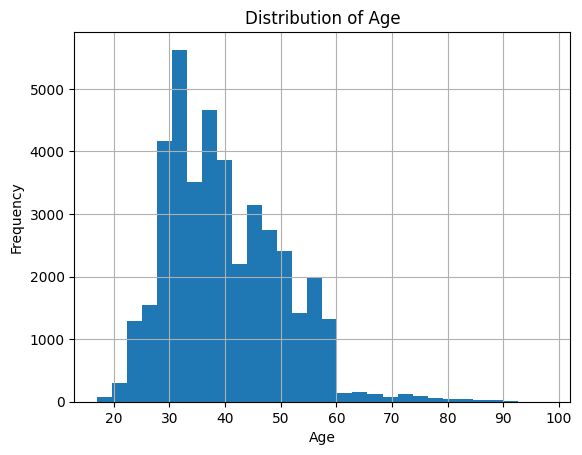

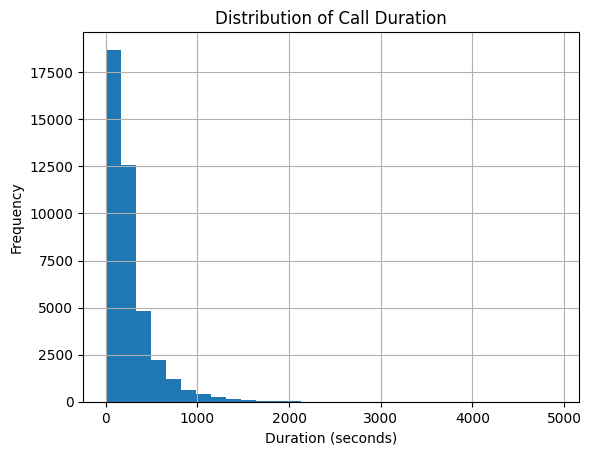

In [34]:
## numerical visualize

# age distribution
df["age"].hist(bins=30)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# duration distribution
df["duration"].hist(bins=30)
plt.title("Distribution of Call Duration")
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency")
plt.show()

The distribution for age is pretty concentrated in the mid-adult range (30-40). This could suggest that the bank may target people who are a bit more financially stable and have young families. This is likely when people are getting married or are beginning to invest their money.

The duration variable is very skewed, showing shorter calls. This pattern suggests that extended interactions may be associated with stronger customer engagement. 

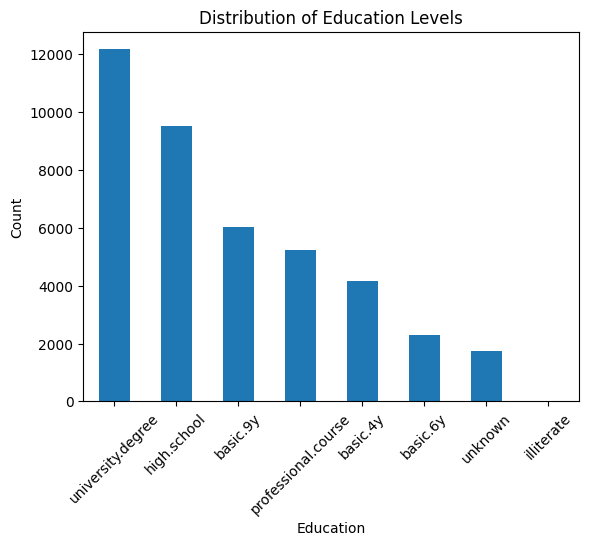

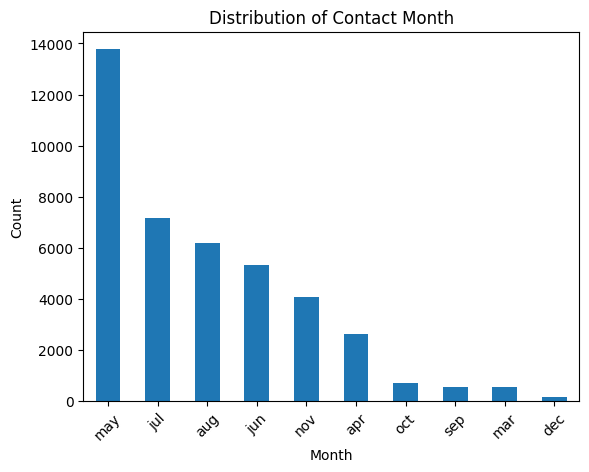

In [35]:
## categorical visualization

# Education distribution
df["education"].value_counts().plot(kind="bar")
plt.title("Distribution of Education Levels")
plt.xlabel("Education")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# month distribution
df["month"].value_counts().plot(kind="bar")
plt.title("Distribution of Contact Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

The distribution of contact month shows that most outreach happens in the late spring and summer, especially in May, July, and August. This could suggest that the bank is strategically targeting customers during times when they may be more financially active or responsive, such as after tax season or during mid-year financial planning. 

The education distribution is heavily concentrated in university degree and high school categories. This suggests that the campaign is reaching a fairly broad but still relatively educated customer base. Education may be an important factor because individuals with higher levels of education could be more comfortable with financial products or long-term investments. It is important to note that there is also a good portion of “unknown” values, which likely represent missing or unavailable information rather than a meaningful category. 

One variable that needs special consideration is duration, which measures how long the last call lasted. While this is likely very predictive, it is only known after the call has already happened. Since the goal is to predict subscription before or during the contact decision, using duration would introduce data leakage and lead to unrealistic model performance. Because of this, it will likely need to be excluded from the final model.


# Task 3: Data Splitting

In [36]:
## define x and y 

X = df.drop(columns=["y"]).copy()
y = df["y"].map({"no": 0, "yes": 1}).astype(int)

print("X shape:", X.shape)
print("y mean (yes-rate):", y.mean())


X shape: (41188, 20)
y mean (yes-rate): 0.11265417111780131


In [37]:
## split + sanity check

from sklearn.model_selection import train_test_split

# first split: 80% training, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# second split: temporary into validation and test (10% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# check size
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

# check class balance
print("\nYes-rate:")
print("Overall:", y.mean())
print("Train:", y_train.mean())
print("Validation:", y_val.mean())
print("Test:", y_test.mean())

Train: (32950, 20)
Validation: (4119, 20)
Test: (4119, 20)

Yes-rate:
Overall: 0.11265417111780131
Train: 0.11265553869499241
Validation: 0.11264870114105366
Test: 0.11264870114105366


I split the dataset into training, validation, and test sets before preprocessing. This helps prevent data leakage, since steps like encoding, scaling, or feature engineering should only be learned from the training data. If these were done before splitting, the model would use information from the validation and test sets, which would lead to overly positive results.

An 80/10/10 split was used so that most of the data is available for training, while still keeping separate validation and test sets. The validation set will be used for model and pipeline decisions, and the test set will remain untouched for the final evaluation.
 I used stratified sampling because the target variable is imbalanced, with fewer clients subscribing than not. This keeps the class proportions similar across each split and makes evaluation more reliable.

# Task 4: Managing Missing Values

In [38]:
# explicit missing values (NaN) in training data

missing_explicit = X_train.isna().sum().sort_values(ascending=False)
missing_explicit[missing_explicit > 0]

Series([], dtype: int64)

In [39]:
# show implicit missing values ("unknown") in categorical features
implicit_missing = {}

for col in X_train.select_dtypes(include="object").columns:
    implicit_missing[col] = (X_train[col] == "unknown").sum()

pd.Series(implicit_missing).sort_values(ascending=False)

default        6940
education      1397
housing         796
loan            796
job             265
marital          65
contact           0
month             0
day_of_week       0
poutcome          0
dtype: int64

In [40]:
# find percentage of implicit missing values
implicit_pct = {}

for col in X_train.select_dtypes(include="object").columns:
    implicit_pct[col] = (X_train[col] == "unknown").mean()

pd.Series(implicit_pct).sort_values(ascending=False)

default        0.210622
education      0.042398
housing        0.024158
loan           0.024158
job            0.008042
marital        0.001973
contact        0.000000
month          0.000000
day_of_week    0.000000
poutcome       0.000000
dtype: float64

Missing values were analyzed using only the training data to avoid any kind of data leakage. This is important because any imputation or transformation that learns patterns from the full dataset could introduce information from the validation or test sets. As discussed in the lectures, preprocessing steps should only be run on the training data and then later applied to the other splits.

The dataset contains very few explicit missing values in the form of NaN. However, several categorical variables contain implicit missing values represented as “unknown.” These likely reflect unavailable or unrecorded information rather than meaningful categories. The extent of missingness varies across features, with some variables having only a small proportion of unknown values and others having a more noticeable share. 

For categorical variables, the main strategy will be to treat “unknown” as a separate category rather than imputing. I am choosing this approach because the absence of information could potentially have a predictive value. For example, not reporting employment or education could be related to financial behavior or engagement with the bank. I considered replacing “unknown” with the most frequent category. However, I decided not to because it assumes that missing values behave similarly to the majority group, which may not be true and could mess up the distribution of the data. For numerical variables, if missing values appear later, imputation using the median or similar stats would be used. Median imputation is robust to skewed distributions and works with logistic regression. These statistics would be computed only on the training data and then applied to the validation and test sets.

My strategy separates data cleaning decisions from modeling decisions. Cleaning focuses on identifying true missing or inconsistent entries, while modeling considers whether missingness itself may carry useful predictive information.

# Task 5: Encoding Categorical Variables

In [66]:
## separate categorical variables
cat_cols = X_train.select_dtypes(include="object").columns.tolist()

print("Categorical variables:")
print(cat_cols)

## education as ordinal, rest as nominal
ordinal_cols = ["education"]
nominal_cols = [col for col in cat_cols if col not in ordinal_col]

print("Ordinal:", ordinal_cols)
print("Nominal:", nominal_cols)


Categorical variables:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Ordinal: ['education']
Nominal: ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [67]:
from sklearn.preprocessing import OrdinalEncoder

## show what education levels there are
sorted(df["education"].unique())

['basic.4y',
 'basic.6y',
 'basic.9y',
 'high.school',
 'illiterate',
 'professional.course',
 'university.degree',
 'unknown']

In [71]:
## define order of education

edu_order = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'professional.course', 'university.degree', 'unknown']
ordinal_encoder = OrdinalEncoder(categories=[edu_order])

In [73]:
## fit training only (ordinal)
X_train_ord = ordinal_encoder.fit_transform(X_train[ordinal_cols])

## validation AND test (ordinal)
X_val_ord = ordinal_encoder.transform(X_val[ordinal_cols])
X_test_ord = ordinal_encoder.transform(X_test[ordinal_cols])

In [74]:
from sklearn.preprocessing import OneHotEncoder

onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# fit only on training (nominal)
X_train_nom = onehot_encoder.fit_transform(X_train[nominal_cols])

# apply to validation and test (nominal)
X_val_nom = onehot_encoder.transform(X_val[nominal_cols])
X_test_nom = onehot_encoder.transform(X_test[nominal_cols])

In [75]:
# ORDINAL DF
X_train_ord = pd.DataFrame(X_train_ord, columns=ordinal_cols, index=X_train.index)
X_val_ord = pd.DataFrame(X_val_ord, columns=ordinal_cols, index=X_val.index)
X_test_ord = pd.DataFrame(X_test_ord, columns=ordinal_cols, index=X_test.index)

# NOMINAL DF
nominal_feature_names = onehot_encoder.get_feature_names_out(nominal_cols)
X_train_nom = pd.DataFrame(X_train_nom, columns=nominal_feature_names, index=X_train.index)
X_val_nom = pd.DataFrame(X_val_nom, columns=nominal_feature_names, index=X_val.index)
X_test_nom = pd.DataFrame(X_test_nom, columns=nominal_feature_names, index=X_test.index)

# combine them togther
X_train_encoded = pd.concat([X_train_ord, X_train_nom], axis=1)
X_val_encoded = pd.concat([X_val_ord, X_val_nom], axis=1)
X_test_encoded = pd.concat([X_test_ord, X_test_nom], axis=1)

print("Encoded training shape:", X_train_encoded.shape)

Encoded training shape: (32950, 46)


I converted the categorical variables into numerical variables so that the model was able to train them. I am treating education as ordinal because the level of education is linear. This means that the model can predict any progression between the variables because education is not just a category. 

The rest of the variables were treated as nominal categories and I used one-hot encoding. This helps to minimize any bias and helps it become easier for the model to interpret, as the categories now have coefficients. 

The encoders were fitted on the training data and then applied to both the validation and test sets that I split up. This is crucial because encoding learns patterns from the data, such as which categories exist. If I fitted the encoders on the full dataset, it could introduce data leakage and make the model performance look better than it really is. 

Encoding increases the dimensionality of the dataset because one-hot encoding creates a separate feature for each category, especially for variables like job or month with many levels. While this makes the model more complex, it also improves interpretability since each category has its own coefficient, making it easier to understand how different customer groups relate to the probability of subscription. Treating education as ordinal also helps because the coefficient reflects a meaningful progression rather than unrelated categories. Finally, encoding changes the types of decision boundaries a linear model can represent. Even though the model is still linear, one-hot encoding allows it to separate categories more flexibly, while ordinal encoding allows it to capture ordered trends.